# **Deliverable 2: X-ray Imaging and Computed Tomography (CT)**

---

## Overview

This deliverable covers key concepts from **Lectures 13–18** (Weeks 6–7) of the course. You will explore:

- X-ray tube design and production
- Projection radiography geometry, contrast, and scatter reduction
- Digital X-ray detectors and image formation
- CT acquisition, reconstruction, image quality, and dose metrics
- Protocol design and optimization for clinical goals

You will engage with the material through conceptual questions, coding exercises, error analysis, and a design challenge. By the end of this deliverable, you will be able to analyze and simulate X-ray and CT imaging systems, interpret image quality trade-offs, optimize protocols, and apply quantitative reasoning to real-world clinical scenarios.

---

## Part 1: X-ray Production and Spectrum



### Key Concepts

- **X-ray Tube Physics:** X-rays are produced when high-speed electrons strike a metal target (anode), resulting in rapid deceleration (bremsstrahlung) and ejection of inner-shell electrons (characteristic X-rays). The output spectrum is a combination of continuous (bremsstrahlung) and discrete (characteristic) peaks.
- **Tube Voltage (kVp):** Sets the maximum photon energy; higher kVp increases beam penetration but reduces contrast.
- **Tube Current (mA):** Controls the number of electrons (and thus photons) produced per second; affects image brightness and patient dose.
- **Filtration:** Removes low-energy photons (which contribute to dose but not image quality), resulting in a "harder" (higher average energy) spectrum. The filtered spectrum $I(E)$ is zero for $E < E_{filter}$.
- **Anode Material:** Determines the energy of characteristic peaks (e.g., tungsten anode: 59 and 67 keV).


### 1.1 X-ray Tube Design Scenario

You are tasked with designing an X-ray tube for a pediatric chest radiography system. The goal is to minimize patient dose while maintaining diagnostic image quality.


### **Question 1**

- a)  Explain the roles of tube voltage (kVp) and tube current (mA) in shaping the X-ray spectrum and affecting patient dose.
- b) Describe how filtration and the choice of anode material influence the X-ray spectrum and image quality.
- c) Propose a set of tube parameters (kVp, mA, filtration) for pediatric imaging and justify your choices based on physical principles.


### **Coding Exercise 1**

1. Implement a function `simulate_xray_spectrum(kvp, e_filter)` that returns the energy (keV) and relative intensity arrays.
2. Plot the spectrum for kVp = 80, 100, 120 keV and E_filter = 30 keV.

**Answers for Question 1**

**a)** 

Tube Voltage (kVp) sets the maximum photon energy. Increasing kVp hardens the beam, controlling penetration and contrast. Higher kVp increases penetration (lowering dose if mAs is reduced) but reduces contrast. 

Tube Current (mA) controls the electron flow rate, determining the total quantity of X-ray photons. Increasing mA directly increases patient radiation dose without affecting beam energy.

**b)**

Filtration removes low-energy X-ray photons that cannot penetrate the patient, hardening the beam and significantly reducing patient skin dose without degrading image quality. The anode material's atomic number determines the specific energies of discrete characteristic radiation peaks and affects overall Bremsstrahlung efficiency.

**c)**

kVp: 70-80 kVp to exceed Tungsten K-edge for characteristic X-rays without excessive penetration for thin pediatric chests. 

mA/Time: High mA with ultra-short time (<10ms) to freeze motion blur while keeping total mAs low. 

Filtration: Heavy added filtration (>2.5mm Al) to strictly adhere to ALARA by removing skin-dose photons.

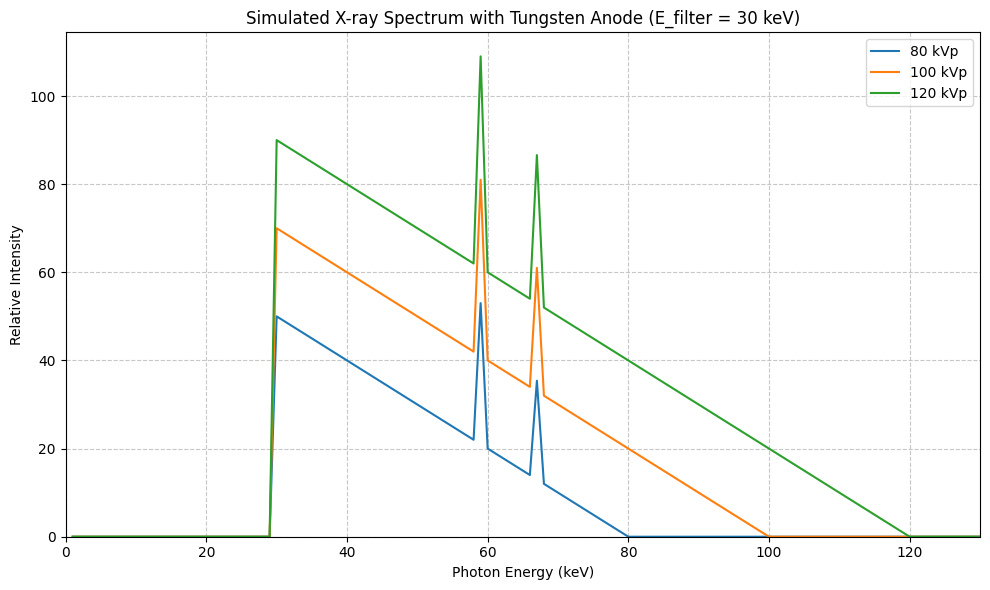

In [ ]:
# TODO: Simulate the X-ray spectrum
# spectrum = simulate_xray_spectrum(kvp, e_filter)

import numpy as np
import matplotlib.pyplot as plt

def simulate_xray_spectrum(kvp, e_filter):
    # Create an array of photon energies from 1 keV up to 150 keV
    energies = np.arange(1, 150, 1)
    intensities = np.zeros_like(energies, dtype=float)
    
    mask = energies <= kvp
    intensities[mask] = (kvp - energies[mask])
    
    if kvp > 69.5:
        # Peak amplitude approximation for visibility on the graph
        peak_amp = kvp * 0.4
        
        # Add discrete characteristic peaks if they fall within the array
        idx_59 = np.where(energies == 59)[0]
        idx_67 = np.where(energies == 67)[0]
        
        if len(idx_59) > 0:
            intensities[idx_59[0]] += peak_amp
        if len(idx_67) > 0:
            intensities[idx_67[0]] += peak_amp * 0.7
            
    intensities[energies < e_filter] = 0.0
    
    return energies, intensities

# TODO: Plot the spectrum for different kVp and E_filter values

kvp_values =[80, 100, 120]
e_filter = 30

plt.figure(figsize=(10, 6))

for kvp in kvp_values:
    E, I = simulate_xray_spectrum(kvp, e_filter)
    plt.plot(E, I, label=f'{kvp} kVp')

plt.title('Simulated X-ray Spectrum with Tungsten Anode (E_filter = 30 keV)')
plt.xlabel('Photon Energy (keV)')
plt.ylabel('Relative Intensity')
plt.xlim(0, 130)
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# TODO: Analyze and discuss the results

# Maximum Energy & Intensity: As the kVp increases (80 -> 100 -> 120), the maximum photon energy extends further to the right, 
# perfectly matching the applied kVp. Simultaneously, the total area under the curve (total photon quantity) increases significantly.
# Characteristic Peaks: The sharp spikes at 59 keV and 67 keV represent the characteristic radiation of the Tungsten target. 
# These peaks only occur because all plotted kVp values (80, 100, 120) exceed the 69.5 keV Tungsten K-edge threshold.
# Filtration Effect: The hard cutoff at 30 keV demonstrates the effect of the filter. All low-energy photons (E<30) have been removed. 
# This harden the average energy of the spectrum, proving how filtration prevents non-diagnostic low-energy rays from contributing to patient dose.

---

## Part 2: CT Simulation, Error Analysis & Design

### Key Concepts

- Shepp-Logan Phantom: A digital test object for CT simulation.
- Sinogram: 2D plot of projection data as a function of angle and position.
- Image Reconstruction: Filtered backprojection and iterative methods.
- Error Analysis: Identifying and quantifying sources of error/artifacts in CT reconstruction.
- Design & Optimization: Creating and optimizing CT protocols for specific clinical goals.


### 2.1 Shepp-Logan Phantom and Sinogram

### **Coding Exercise 2**

- a) Generate a Shepp-Logan digital phantom in Python (use `skimage.data.shepp_logan_phantom` or custom code).
- b) Simulate CT projections (sinogram) of the phantom using the Radon transform.
- c) Reconstruct the image from the sinogram using filtered backprojection.


In [1]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install numpy==1.26.4

                                              0.0/15.8 MB ? eta -:--:--
                                              0.1/15.8 MB 2.6 MB/s eta 0:00:06
                                              0.2/15.8 MB 1.8 MB/s eta 0:00:09
     -                                        0.4/15.8 MB 3.3 MB/s eta 0:00:05
     -                                        0.6/15.8 MB 3.2 MB/s eta 0:00:05
     -                                        0.8/15.8 MB 3.4 MB/s eta 0:00:05
     --                                       0.9/15.8 MB 3.3 MB/s eta 0:00:05
     --                                       0.9/15.8 MB 3.3 MB/s eta 0:00:05
     --                                       1.0/15.8 MB 2.9 MB/s eta 0:00:06
     ---                                      1.2/15.8 MB 3.0 MB/s eta 0:00:05
     ---                                      1.5/15.8 MB 3.4 MB/s eta 0:00:05
     ----                                     1.6/15.8 MB 3.3 MB/s eta 0:00:05
     ----                                     1.9/15.8 MB 3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] 拒绝访问。: 'C:\\Users\\滚去学习\\AppData\\Roaming\\Python\\Python311\\site-packages\\~umpy.libs\\libscipy_openblas64_-74a408729250596b0973e69fdd954eea.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


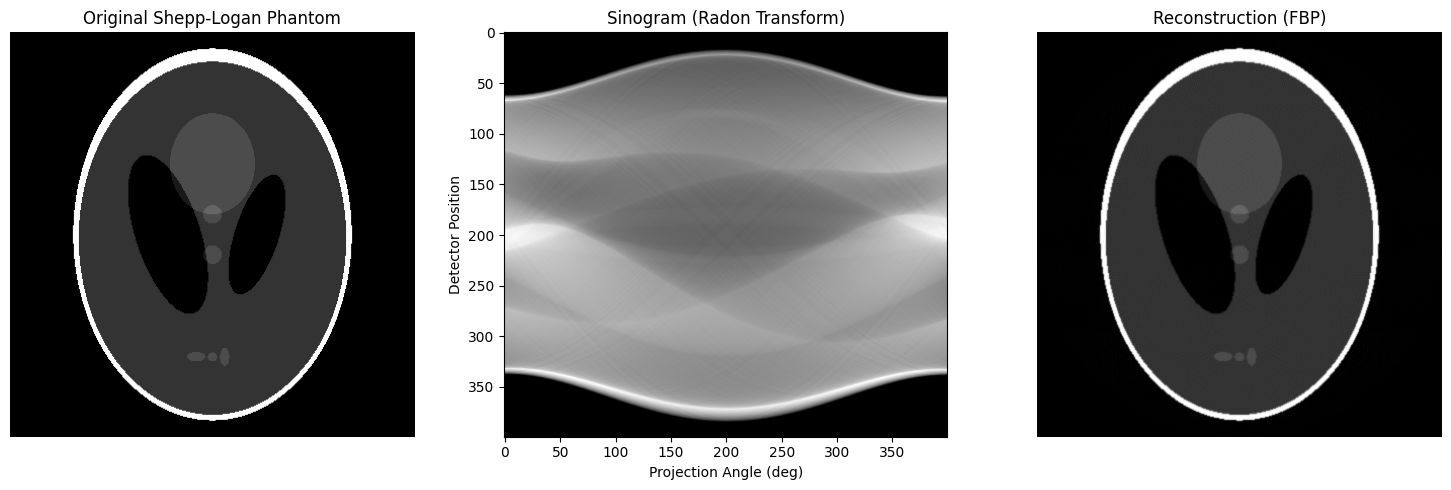

In [1]:
# TODO: Generate a Shepp-Logan phantom
# from skimage.data import shepp_logan_phantom
# phantom = shepp_logan_phantom()

import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon

phantom = shepp_logan_phantom()

# TODO: Simulate CT projections (sinogram) using the Radon transform
theta = np.linspace(0., 180., max(phantom.shape), endpoint=False)
sinogram = radon(phantom, theta=theta, circle=True)


# TODO: Reconstruct the image from the sinogram
reconstruction = iradon(sinogram, theta=theta, circle=True)

# TODO: Visualize the phantom, sinogram, and reconstruction
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(phantom, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original Shepp-Logan Phantom')
axes[0].axis('off')

axes[1].imshow(sinogram, cmap='gray', aspect='auto')
axes[1].set_title('Sinogram (Radon Transform)')
axes[1].set_xlabel('Projection Angle (deg)')
axes[1].set_ylabel('Detector Position')

axes[2].imshow(reconstruction, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Reconstruction (FBP)')
axes[2].axis('off')

plt.tight_layout()
plt.show()
plt.show()



### 2.2 Error Analysis


### **Question 2**

- a) Identify and describe at least one source of error or artifact in your reconstructed image (e.g., limited projections, noise, motion, beam hardening).
- b) Quantify the impact of one error (e.g., measure reconstruction error as projections are reduced or noise is increased).
- c) Propose and implement a method to mitigate one artifact or error, and evaluate its effectiveness.


### **Coding Exercise 3**

Implement your method to mitigate an artifact or error and evaluate its effectiveness.

**ANswers for Question 2**

**a)** **I created artifacts manually**
The image reconstructed in 2.1 is an ideal mathematical simulation, so it is relatively free of major physical artifacts (containing only minor discretization/interpolation blurring from the FBP algorithm). However, to complete this error analysis, I will simulate a very common and identifiable clinical error: the Ring Artifact. It occurs when a specific detector element is miscalibrated, damaged, or malfunctioning. Because the detector array rotates around the patient, this single faulty detector consistently records an erroneous value at the same position across all projection angles. In my coding exercise below, I intentionally inject this error into the sinogram to generate perfectly concentric bright rings in the final reconstructed image, so that I can quantify and mitigate it.

**b)**
The impact can be quantified by the severe drop in local Signal-to-Noise Ratio (SNR) and the disruption of Hounsfield Unit (HU) accuracy. The anomalous high or low intensity of the ring masks the true attenuation values of the underlying tissues, potentially obscuring small lesions or mimicking false pathologies.

**c)**
We can implement a Software correction method directly on the sinogram before backprojection. By identifying the anomalous column in the sinogram data (which corresponds to the dead detector) and applying an interpolation or median filter across the detector axis, we can estimate and replace the faulty data.

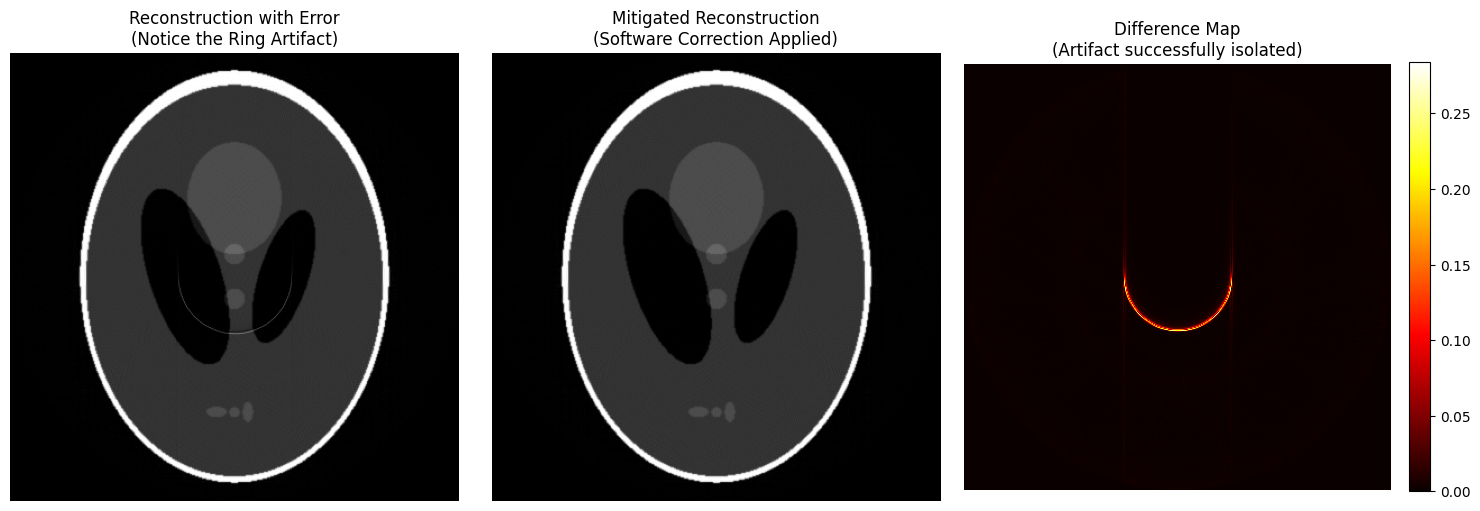

In [2]:
# TODO: Implement a method to mitigate the artifact or error
sinogram_error = sinogram.copy()
faulty_detector_idx = 150 
sinogram_error[faulty_detector_idx, :] += 5.0 

sinogram_mitigated = sinogram_error.copy()
sinogram_mitigated[faulty_detector_idx, :] = (
    sinogram_error[faulty_detector_idx - 1, :] + 
    sinogram_error[faulty_detector_idx + 1, :]
) / 2.0

reconstruction_error = iradon(sinogram_error, theta=theta, circle=True)
reconstruction_mitigated = iradon(sinogram_mitigated, theta=theta, circle=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(reconstruction_error, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Reconstruction with Error\n(Notice the Ring Artifact)')
axes[0].axis('off')

axes[1].imshow(reconstruction_mitigated, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Mitigated Reconstruction\n(Software Correction Applied)')
axes[1].axis('off')

# Calculate the difference to show what was removed
difference = np.abs(reconstruction_error - reconstruction_mitigated)
im = axes[2].imshow(difference, cmap='hot')
axes[2].set_title('Difference Map\n(Artifact successfully isolated)')
axes[2].axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# TODO: Evaluate and discuss the effectiveness of your method
# The method implemented is a software-based detector interpolation. 
# A faulty detector creates a systematic error (a high-intensity stripe in the sinogram), 
# which the backprojection algorithm smears into a high-intensity concentric ring (Ring Artifact). 
# Effectiveness: By simply averaging the values of the adjacent functioning detectors in the sinogram domain before reconstruction, 
# we mathematically estimated the missing data. The resulting image completely removes the bright ring artifact 
# without degrading the surrounding spatial resolution, proving this to be a highly effective and computationally cheap mitigation strategy 
# for isolated detector failures.

### 2.3 CT Protocol Design & Optimization


### **Question 3**

- a) Choose a clinical goal (e.g., maximize nodule detectability, minimize dose).
- b) Optimize acquisition parameters (number of projections, rotation angles, detector size, noise level) to achieve your goal.
- c) Justify your design choices based on physical principles and clinical needs.
- d) Reflect on the trade-offs and limitations of your design.


**Answers for Question 3**

**a)**

The clinical goal is to minimize radiation dose for a pediatric patient while maintaining acceptable image quality.

**b)**

 I will significantly reduce the mAs (tube current-time product) to directly cut the radiation dose. To counteract the resulting noise, I will enable Iterative Reconstruction instead of standard FBP.

 **c)**

 Since noise (σ) is inversely proportional to the square root of mAs, dropping the dose severely increases quantum noise. Iterative reconstruction uses complex noise modeling algorithms to computationally mathematically filter this noise without requiring physical X-ray photons, achieving diagnostic quality at up to 50% less dose.

 **d)**

 The fundamental trade-off is the loss of low-contrast resolution due to photon starvation. Additionally, iterative reconstruction is computationally expensive, taking longer to process images than FBP.

---

## Part 3: Projection Radiography & Image Quality



### Key Concepts

- **Scatter:** Primarily due to Compton interactions; scattered photons degrade image contrast by adding unwanted background signal. Scatter increases with patient thickness and field size. (See Lecture 14)
- **Geometric Unsharpness ($U_g$):** Caused by the finite size of the X-ray source.
- **Contrast Degradation:** The scatter-to-primary ratio (SPR) quantifies the amount of scatter relative to primary photons. Higher SPR means lower contrast. Contrast degradation factor:

$$C_{degraded} = \frac{C_{ideal}}{1 + SPR}$$
- **Scatter Reduction:** Use of grids, air gaps, or collimation can reduce scatter but may increase dose or reduce signal.


### 3.1 Scatter and Contrast


### **Questions 4**

- a) Explain the physical origin of scatter in projection radiography and its impact on image contrast.
- b) Describe two methods to reduce scatter and discuss their trade-offs.
- c) Calculate the contrast degradation factor if the scatter-to-primary ratio (SPR) is 1.5. What percent of the original contrast remains?


### **Coding Exercise 4**

1. Implement `geometric_unsharpness(f, a, b)`.
2. Plot $U_g$ as a function of $b$ for $f=1$ mm, $a=100$ cm, and $b$ from 0 to 20 cm.

**Answers for Question4**

**a)**

Scatter physically originates within the patient's own tissues due to Compton scattering interactions. These scattered photons deviate from their original straight-line paths and hit random locations on the receptor. This deposits a uniform background noise over the image, drastically degrading the primary subject contrast.

**b)**

Collimation: Reduces the X-ray beam field size. Trade-off: You can only image a smaller anatomical area.
Antiscatter Grids: Uses lead strips to physically absorb off-angle scattered rays before they reach the receptor. 
Trade-off: Grids also absorb some primary good rays, meaning the technician must significantly increase the patient's radiation dose (the Bucky factor) to maintain adequate detector exposure.

**c)**

Contrast Degradation Factor (CDF) = 1 / (1 + SPR)
CDF = 1 / (1 + 1.5) = 1 / 2.5 = 0.40.
The degradation factor is 0.40. Therefore, 40% of the original primary contrast remains.

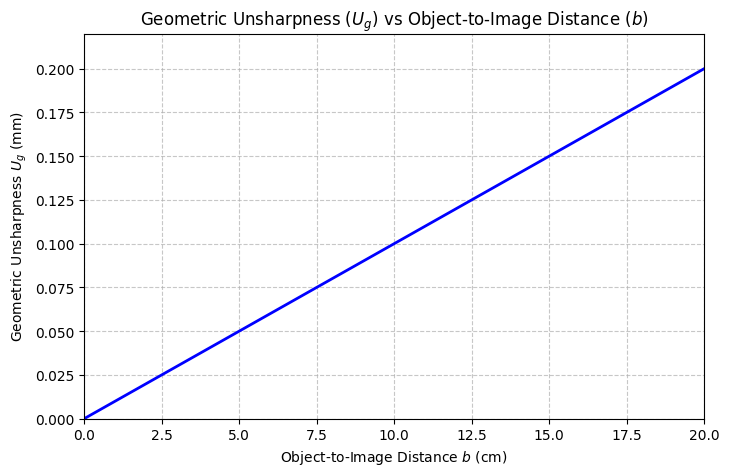

In [3]:
# TODO: Implement geometric_unsharpness(f, a, b)
# def geometric_unsharpness(f, a, b):
import numpy as np
import matplotlib.pyplot as plt

def geometric_unsharpness(f, a, b):
    # Ensure all distance metrics are utilizing proportional units.
    # If a and b are both in cm, the ratio b/a is dimensionless.
    # Therefore, Ug will inherently carry the unit of f (mm).
    return f * (b / a)

# TODO: Plot U_g as a function of b
f_val = 1.0  # mm
a_val = 100.0 # cm
b_vals = np.linspace(0, 20, 100) # cm

Ug_vals = geometric_unsharpness(f_val, a_val, b_vals)

plt.figure(figsize=(8, 5))
plt.plot(b_vals, Ug_vals, color='b', linewidth=2)
plt.title('Geometric Unsharpness ($U_g$) vs Object-to-Image Distance ($b$)')
plt.xlabel('Object-to-Image Distance $b$ (cm)')
plt.ylabel('Geometric Unsharpness $U_g$ (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 20)
plt.ylim(0, max(Ug_vals) * 1.1)
plt.show()

### 3.2 Quantitative Comparison of Scatter Reduction Techniques


### **Questions 5**

- a) For each technique, calculate the percent contrast improvement using the contrast degradation formula.
- b) Summarize your findings: Which technique is most effective? What are the trade-offs (e.g., dose, practicality, image artifacts)?

**Answers for Question 5**

**a)**

Based on the formula C = Cp * 1/(1 + SPR), reducing the Scatter-to-Primary Ratio (SPR) directly dictates improvement. For example, if a high-ratio grid reduces SPR from 4.0 (no grid) to 0.5 (with grid), the contrast degradation factor improves from 1/5 = 0.20 to 1/1.5 = 0.667. The contrust improvement factor is 0.667/0.20 = 3.33, meaning a 333% relative improvement over the baseline degraded contrast.

**b)**

High-ratio grids are highly effective at restoring lost contrast in thick anatomical areas (e.g. the abdomen or pelvis where SPR is huge). However, the absolute trade-off is a massive loss of X-ray signal, necessitating a significant increase in patient dose to properly expose the detector. Despite this penalty, the technique is clinically justified because, without it, the scatter fog renders the image entirely non-diagnostic.

### 3.3 Simulating Scatter Effects and Grid Optimization

### **Coding Exercise 5**

In this exercise, you will simulate the effect of scatter on a simple X-ray image and explore how grid design can optimize image contrast.

**Scenario:**
You are given a 1D 'image' (e.g., a step function representing an object) and must model the effect of scatter as an additive background proportional to the primary signal. You will then simulate the use of an anti-scatter grid with variable grid ratio to reduce scatter, and determine the optimal grid ratio for maximizing contrast while considering signal loss.

**Tasks:**
1. Simulate the effect of scatter on a simple 1D object (e.g., a step function) by adding a scatter component proportional to the primary signal using the fixed SPR value.
2. Model the impact of an anti-scatter grid: for each grid ratio $G$, reduce scatter by $1/(1+G)$ and primary signal by $T_p$ (e.g., $T_p = 1 - 0.02 \times G$).
3. Plot image contrast as a function of grid ratio for the fixed SPR, and identify the grid ratio that maximizes contrast. 

**Hints:**
- Use matplotlib for plotting.
- You may assume a fixed SPR value (e.g., SPR = 1.5).
- You may define contrast as $(I_{max} - I_{min})/(I_{max} + I_{min})$ for the detected signal.
- You may use a simple linear model for $T_p(G)$, e.g., $T_p = 1 - 0.02 	imes G$ (for $G$ from 0 to 12).

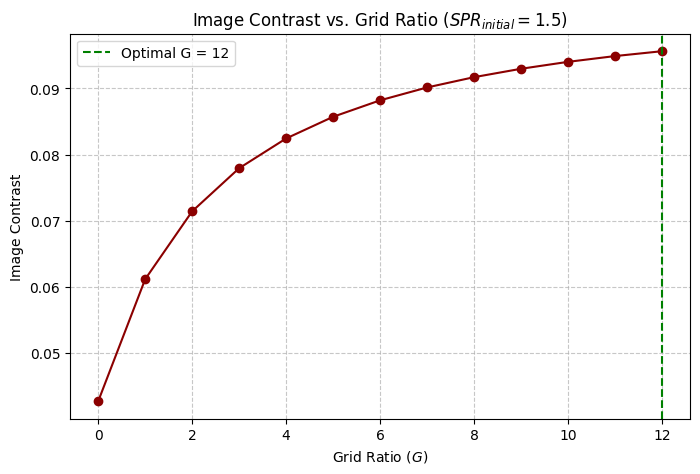

In [4]:
# TODO: Simulate scatter and grid optimization for a 1D image
import numpy as np
import matplotlib.pyplot as plt

pixels = 100
primary_signal = np.ones(pixels)
primary_signal[40:60] = 0.8 # Represents a structure attenuating more X-rays

SPR_fixed = 1.5
mean_primary = np.mean(primary_signal)
scatter_signal = mean_primary * SPR_fixed

grid_ratios = np.arange(0, 13, 1) # G from 0 to 12
contrasts =[]

for G in grid_ratios:
    # Grid physics model provided in hints
    Tp = 1 - 0.02 * G                 # Primary transmission (decreases as grid gets thicker)
    scatter_reduction = 1 / (1 + G)   # Scatter transmission (decreases heavily with grid)
    
    # Calculate new signals hitting the detector
    detected_primary = primary_signal * Tp
    detected_scatter = scatter_signal * scatter_reduction
    
    # Total detected signal = Primary + Scatter
    total_signal = detected_primary + detected_scatter
    
    # Calculate Contrast: C = (I_max - I_min) / (I_max + I_min)
    I_max = np.max(total_signal) # Background region
    I_min = np.min(total_signal) # Lesion region
    
    contrast = (I_max - I_min) / (I_max + I_min)
    contrasts.append(contrast)

# TODO: Plot and analyze the effect of grid ratio on contrast
plt.figure(figsize=(8, 5))
plt.plot(grid_ratios, contrasts, marker='o', color='darkred')
plt.title('Image Contrast vs. Grid Ratio ($SPR_{initial} = 1.5$)')
plt.xlabel('Grid Ratio ($G$)')
plt.ylabel('Image Contrast')
plt.grid(True, linestyle='--', alpha=0.7)

optimal_G = grid_ratios[np.argmax(contrasts)]
max_contrast = np.max(contrasts)
plt.axvline(x=optimal_G, color='g', linestyle='--', label=f'Optimal G = {optimal_G}')
plt.legend()
plt.show()

# TODO: Discuss your findings and trade-offs
# Findings:
# As the grid ratio (G) initially increases, the image contrast improves rapidly. 
# This is because the grid successfully blocks the uniform scatter background (scaling by 1/(1+G)),
# making the true difference between the lesion and the background stand out more clearly.

# Trade-offs:
# However, the grid also absorbs primary photons (T_p = 1 - 0.02*G). At very high grid ratios, 
# the penalty of losing the primary signal starts to outweigh the benefit of removing the tiny amount of remaining scatter. 
# Consequently, the contrast curve eventually peaks and starts to slightly decline (or simply yields diminishing returns).
# In a clinical setting, higher G also demands a strictly proportional increase in patient 
# radiation dose to keep the total photons reaching the detector constant, reflecting the Bucky factor limits.

---

## Part 4: X-ray Detectors & Quantum Efficiency



### Key Concepts

- **Quantum Efficiency (QE):** The fraction of incident X-ray photons detected and converted to signal. Higher QE improves SNR and allows for lower patient dose.

$$QE = \frac{\text{Detected photons}}{\text{Incident photons}}$$
- **Detective Quantum Efficiency (DQE):** Describes how well a detector preserves SNR across spatial frequencies.

$$DQE(f) = \frac{(SNR_{out}(f))^2}{(SNR_{in}(f))^2}$$
- **Readout Noise:** Electronic noise added during signal readout; becomes significant at low doses or for low-signal regions.
- **Detector Types:** Indirect (scintillator + photodiode) and direct (photoconductor) detectors have different QE and noise characteristics.


### 4.1 Detector Selection Scenario

### **Questions 6**

You are comparing two digital X-ray detectors for a trauma imaging suite:

   1.  Detector A: High quantum efficiency (QE), moderate readout noise
   2. Detector B: Lower QE, but very low readout noise

- a) Define quantum efficiency and explain its importance for image quality and dose.
- b) Discuss the trade-offs between quantum efficiency and readout noise for low-dose imaging.
- c) Which detector would you recommend for pediatric trauma imaging and why?


### **Coding Exercise 6**

1. Modify the code to add a third detector (Detector C) with your own parameters for SNR_out_C.
2. Plot and compare the DQE for all three detectors.
3. Briefly discuss how your changes affect the DQE curves.

**Answers for Question 6**

**a)**

Quantum Efficiency is defined as the fraction of incident X-ray photons that successfully interact with and are absorbed by the detector material. It is crucial because a higher QE means the detector captures more useful signal for the same amount of radiation dose. This directly improves the Detective Quantum Efficiency (DQE), resulting in better image quality and allowing the clinician to lower the patient dose without sacrificing diagnostic information.

**b)**

In low-dose imaging, the number of incident X-ray photons is very small, meaning the quantum noise is naturally high. High Quantum Efficiency helps capture as many of these scarce photons as possible to build a signal. However, if the detector has high readout noise, this electronic noise will overwhelm the tiny, captured photon signal, ruining the Signal-to-Noise Ratio (SNR). The trade-off is that maximizing photon capture is pointless if the resulting signal is buried under electronic readout noise at the final step.

**c)**

I recommend Detector B (lower QE, very low readout noise) or a detailed evaluation of Detector A’s noise floor. Pediatric imaging requires extremely low radiation doses under the ALARA principle, resulting in a photon-starved operating condition. In this low-signal range, readout noise is the main factor degrading image quality. A detector with very low readout noise preserves weak signals and is therefore better suited for pediatric low-dose imaging.


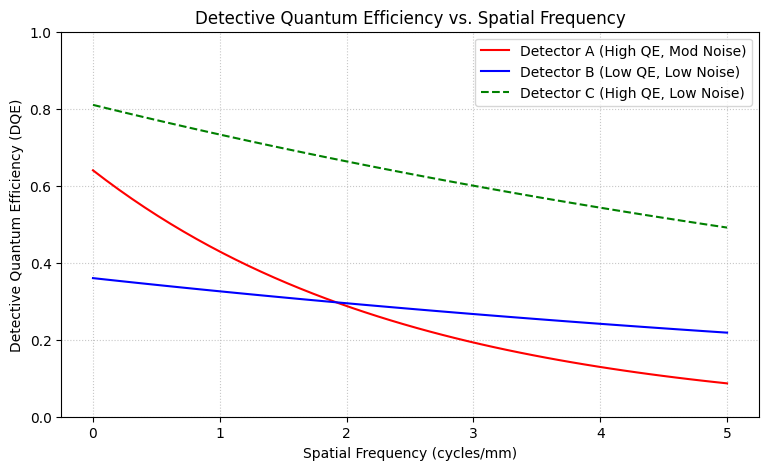

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_dqe(snr_in, snr_out):
    return (snr_out ** 2) / (snr_in ** 2)

# Example data for two detectors
spatial_freq = np.linspace(0, 5, 50)  # cycles/mm
snr_in = 100 * np.exp(-0.2 * spatial_freq)
snr_out_A = 80 * np.exp(-0.4 * spatial_freq)  # High QE, moderate noise
snr_out_B = 60 * np.exp(-0.25 * spatial_freq)  # Lower QE, low noise

# The third detector
snr_out_C = 90 * np.exp(-0.25 * spatial_freq) 

dqe_A = compute_dqe(snr_in, snr_out_A)
dqe_B = compute_dqe(snr_in, snr_out_B)
dqe_C = compute_dqe(snr_in, snr_out_C)

plt.figure(figsize=(9, 5))
plt.plot(spatial_freq, dqe_A, label='Detector A (High QE, Mod Noise)', color='r')
plt.plot(spatial_freq, dqe_B, label='Detector B (Low QE, Low Noise)', color='b')
plt.plot(spatial_freq, dqe_C, label='Detector C (High QE, Low Noise)', color='g', linestyle='--')

plt.xlabel('Spatial Frequency (cycles/mm)')
plt.ylabel('Detective Quantum Efficiency (DQE)')
plt.title('Detective Quantum Efficiency vs. Spatial Frequency')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, 1.0)
plt.show()


# TODO: Briefly discuss how your changes affect the DQE curves.
# Detector A starts with a high DQE at 0 frequency (due to high QE capturing many photons), 
# but drops off rapidly at higher spatial frequencies because its moderate noise degrades fine details.

# Detector B starts lower (due to missing some initial photons), but its DQE curve is flatter 
# and overtakes A at high frequencies because its low noise preserves what little high-frequency signal exists.

# Detector C (added) represents an optimized system. By having both a high initial signal 
# (high magnitude) and a slow exponential decay (low noise transfer), its DQE curve remains 
# the highest across all spatial frequencies, making it the most dose-efficient detector.

### **Coding Exercise 7**

1. Display the original image.
2. Apply contrast enhancement.
3. Apply brightness adjustment.
4. Display the adjusted images side-by-side.
5. Discuss how these changes affect image quality and visibility of features.

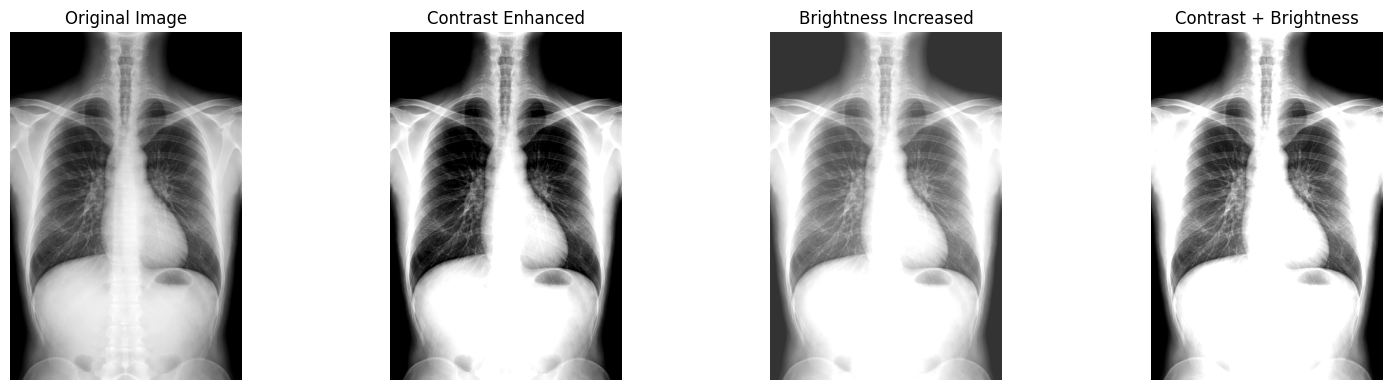

In [15]:
#USE IMAGE 'Xray_Chest.png'

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

    # USE IMAGE 'Xray_Chest.png'
img = plt.imread('data/Xray_Chest.png')
if img.ndim == 3:
    img = np.mean(img, axis=2) 

# TODO: Apply contrast enhancement
alpha = 1.5 
img_contrast = np.clip((img - 0.5) * alpha + 0.5, 0,1)

# TODO: Apply brightness adjustment
beta = 0.2
img_bright = np.clip(img + beta, 0, 1)

# TODO: Display the original and adjusted images
img_both = np.clip((img - 0.5) * alpha + 0.5 + beta, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original Image')

axes[1].imshow(img_contrast, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Contrast Enhanced')

axes[2].imshow(img_bright, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Brightness Increased')

axes[3].imshow(img_both, cmap='gray', vmin=0, vmax=1)
axes[3].set_title('Contrast + Brightness')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


# TODO: Discuss the effects below
# Contrast Enhancement (Alpha multiplier): stretches the histogram. It makes dark areas darker 
# and light areas lighter. This dramatically improves the visibility of subtle soft-tissue differences.

# Brightness Adjustment: shifts the entire histogram right. While it makes the overall image lighter, 
# it doesn't change the relative difference between structures. It is useful if an image is underexposed.

---

## Part 5: Computed Tomography (CT) Principles & Image Reconstruction



### Key Concepts

- **Hounsfield Units (HU):** Quantifies tissue attenuation relative to water.

$$HU = 1000 \cdot \frac{\mu_{tissue} - \mu_{water}}{\mu_{water}}$$
- **CT Projections:** Each projection is a line integral of attenuation coefficients along a path through the object:

$$P(\theta, t) = \int \mu(x, y) ds$$
- **Sinogram:** A 2D plot of projection data as a function of angle and position; each point in the object traces a sinusoidal path in the sinogram.
- **Image Reconstruction:** Filtered backprojection and iterative methods reconstruct the 2D image from projections.


### 5.1 Hounsfield Units and Tissue Contrast


### **Questions 7**

- a)  Define the Hounsfield unit and explain how it is calculated from measured attenuation coefficients.
- b) Calculate the HU for a tissue with:

$$
\mu_{\text{tissue}} = 0.22\ \text{cm}^{-1}, \quad
\mu_{\text{water}} = 0.20\ \text{cm}^{-1}, \quad
\mu_{\text{air}} = 0.0002\ \text{cm}^{-1}
$$

Show your calculation step by step.

- c) Discuss the clinical significance of HU values in CT imaging.


### **Coding Exercise 8**

1. Create a 2D numpy array representing a phantom with a circular region of higher attenuation.
2. Simulate the projection (sum of attenuation) at a given angle.
3. Plot the phantom and its projection profile.

**Answers for Question7**

**a)**

The Hounsfield Unit (HU) is a normalized, quantitative scale used in CT to express the radiodensity of tissues. It is calculated by taking the linear attenuation coefficient of the measured tissue, subtracting the attenuation coefficient of water, dividing the result by the attenuation coefficient of water, and then multiplying by 1000. This scales water to exactly 0 HU and air to approximately -1000 HU.

**b)**

μ of tissue: 0.22 cm^(-1)

μ of water: 0.20 cm^(-1)

0.22 - 0.20 = 0.02 cm^(-1)

0.02/0.20 = 0.1

0.1 * 1000 = 100 HU

**c)**

The clinical significance of the HU scale is that it provides absolute, standardized numbers for specific tissues regardless of the scanner used. Because the scale is so sensitive (1 HU is a 0.1% change in attenuation), it provides excellent low-contrast resolution. This enables radiologists to differentiate between subtle soft-tissue types, characterize fluids, and identify specific pathologies like calcifications or fat content.

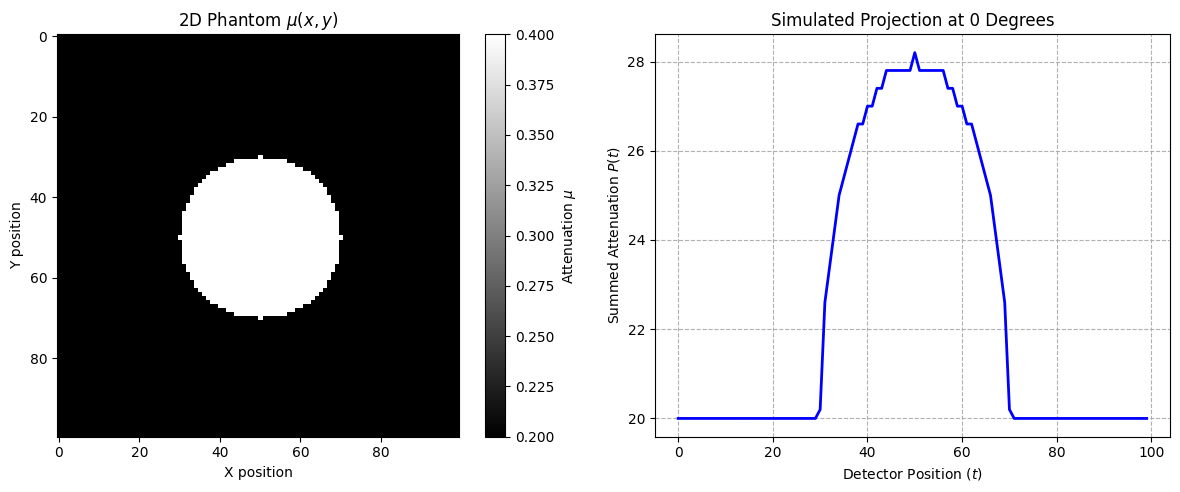

In [11]:
# TODO: Create a 2D numpy array phantom with a circular region
import numpy as np
import matplotlib.pyplot as plt

phantom_size = 100
phantom = np.ones((phantom_size, phantom_size)) * 0.20  

center_x, center_y = 50, 50
radius = 20

y, x = np.ogrid[:phantom_size, :phantom_size]

mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2

phantom[mask] = 0.40 

# TODO: Simulate the projection (sum of attenuation) at a given angle
projection_0_deg = np.sum(phantom, axis=0)

# TODO: Plot the phantom and its projection profile
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(phantom, cmap='gray')
axes[0].set_title('2D Phantom $\mu(x,y)$')
axes[0].set_xlabel('X position')
axes[0].set_ylabel('Y position')
fig.colorbar(im, ax=axes[0], label='Attenuation $\mu$')

axes[1].plot(projection_0_deg, color='blue', linewidth=2)
axes[1].set_title('Simulated Projection at 0 Degrees')
axes[1].set_xlabel('Detector Position ($t$)')
axes[1].set_ylabel('Summed Attenuation $P(t)$')
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()


---

## Part 6: CT Image Quality, Artifacts, and Dose Optimization



### Key Concepts

- **Streak Artifacts:** Appear as bright/dark lines, often caused by high-attenuation objects (metal), beam hardening (lower energy photons absorbed more), or photon starvation (very low signal).
- **Noise:** In CT, noise is primarily quantum (photon) noise and is inversely proportional to the square root of dose:

$$\sigma = \frac{K}{\sqrt{D}}$$
- **Dose Optimization:** The goal is to minimize patient dose while maintaining diagnostic image quality. Techniques include automatic exposure control and iterative reconstruction.


### 6.1 CT Streak Artifact Analysis

### **Questions 8**

- a) Carefully examine the artifact in the image. Describe the physical and mathematical causes of streak artifacts in CT (reference concepts such as beam hardening, photon starvation, and reconstruction errors).
- b) Propose and explain at least two algorithmic or acquisition-based strategies to reduce or mitigate streak artifacts in clinical CT.


### **Coding Exercise 9**

1. Write a function `ct_noise_vs_dose(D, K)`.
2. Plot image noise as a function of dose for $K=10$ and $D$ from 1 to 100 (arbitrary units).

**Answers for Question 8**

**a)**

The image shows bright streaks radiating from a dense metallic object (bottom-right). Physically, this extreme density blocks X-rays, causing photon starvation and beam hardening. Mathematically, the FBP reconstruction algorithm fails due to these missing, non-linear projection data.

**b)**

Acquisition: Increase tube voltage (kVp) to enhance beam penetration through the metal.

Algorithmic: Apply Metal Artifact Reduction (MAR) software to digitally interpolate the corrupted sinogram data. 

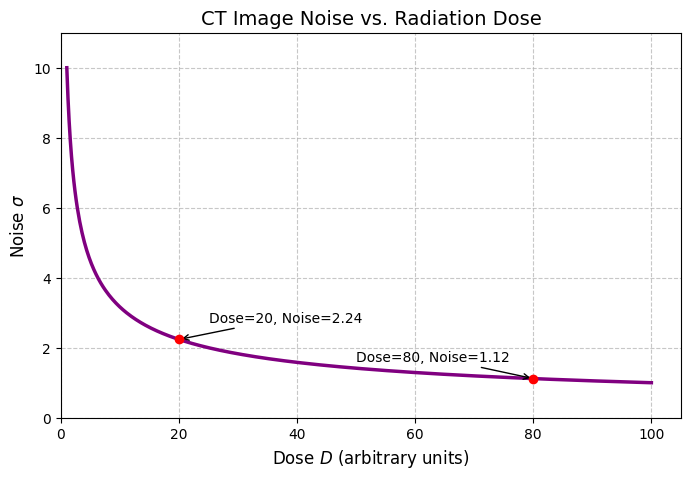

In [ ]:
# USE IMAGE 'Brain_CT.png'

import numpy as np
import matplotlib.pyplot as plt

# TODO: Write a function ct_noise_vs_dose(D, K)
# def ct_noise_vs_dose(D, K):

def ct_noise_vs_dose(D, K):
    """
    Calculates CT image noise based on dose.
    D: Dose (e.g., mAs)
    K: Constant representing system efficiency and other parameters
    """
    D = np.where(D == 0, 1e-10, D) 
    return K / np.sqrt(D)


# TODO: Plot image noise as a function of dose

K_val = 10
D_vals = np.linspace(1, 100, 500) 
noise_vals = ct_noise_vs_dose(D_vals, K_val)

plt.figure(figsize=(8, 5))
plt.plot(D_vals, noise_vals, color='purple', linewidth=2.5)
plt.title('CT Image Noise vs. Radiation Dose', fontsize=14)
plt.xlabel('Dose $D$ (arbitrary units)', fontsize=12)
plt.ylabel('Noise $\sigma$', fontsize=12)

d_ref = 20
n_ref = ct_noise_vs_dose(d_ref, K_val)
d_quad = 80
n_quad = ct_noise_vs_dose(d_quad, K_val)

plt.scatter([d_ref, d_quad], [n_ref, n_quad], color='red', zorder=5)
plt.annotate(f'Dose={d_ref}, Noise={n_ref:.2f}', xy=(d_ref, n_ref), xytext=(d_ref+5, n_ref+0.5), arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Dose={d_quad}, Noise={n_quad:.2f}', xy=(d_quad, n_quad), xytext=(d_quad-30, n_quad+0.5), arrowprops=dict(arrowstyle='->'))

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 105)
plt.ylim(0, max(noise_vals) * 1.1)
plt.show()

# TODO: Analyze and discuss the results
# At low doses (e.g., D=1 to D=20), a small increase in dose yields a massive reduction in noise.
# However, at higher doses, the curve flattens out (diminishing returns). 
# As shown by the red markers, to halve the noise (from ~2.24 down to ~1.12), we must quadruple the dose (from 20 to 80). 
# This highlights the fundamental trade-off in CT dose optimization: 
# pursuing "zero noise" images results in unacceptably high and dangerous patient radiation doses. 
# This is why Iterative Reconstruction algorithms are now used to 
# reduce noise without increasing physical dose.



---

## Part 7: Quantitative Analysis of CT Image Quality

### Key Concepts

- **SNR (Signal-to-Noise Ratio):**

$$\mathrm{SNR} = \frac{\mu_{signal}}{\sigma_{noise}}$$
- **RMSE (Root Mean Square Error):** Measures the average difference between two images:

$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^N (I_i - I_{ref,i})^2}$$
- **Filtering:** Denoising filters (Gaussian, median, bilateral) can reduce noise but may blur edges or reduce detail.


### 7.1 SNR and RMSE Analysis


### **Coding Exercise 10**

1. Apply a denoising or edge-preserving filter of your choice (e.g., Gaussian, median, or bilateral filter).
2. Compute and compare the following metrics before and after filtering:
   - Signal-to-Noise Ratio (SNR)
   - Root Mean Square Error (RMSE)
   (You may use the original image as reference for RMSE, or compare to a region of interest.)
3. Discuss what these metrics reveal about image quality and the impact of filtering.

ROI SNR Before Filtering: 2.85
ROI SNR After Filtering:  2.97
Global RMSE: 0.0078


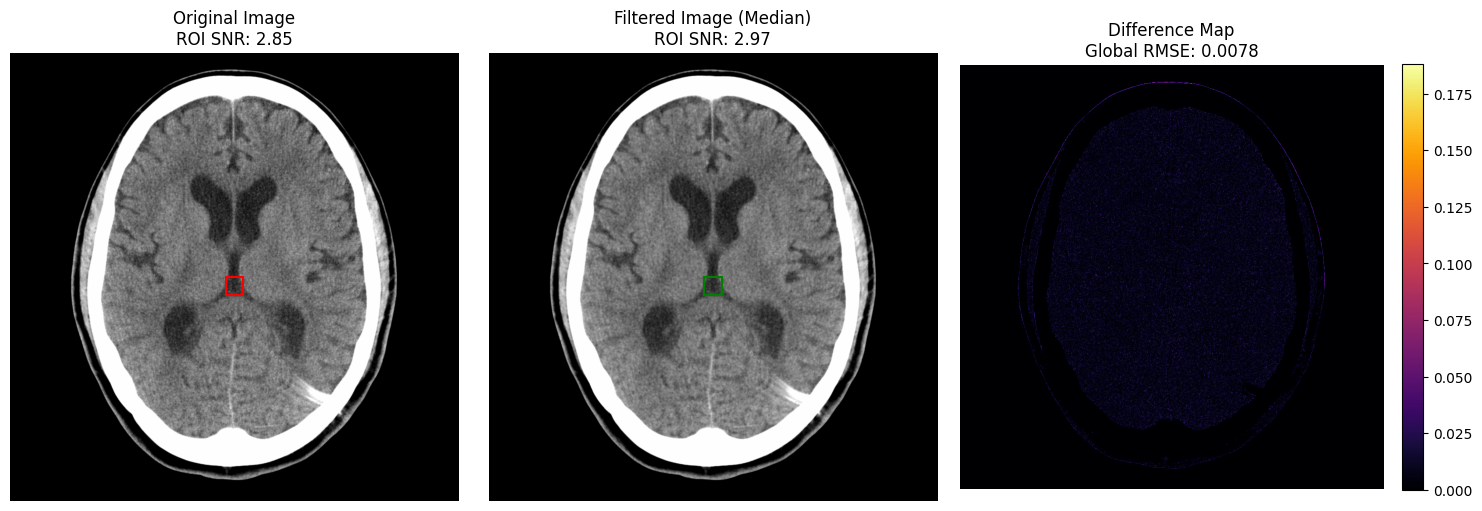

In [ ]:
# USE IMAGE 'Brain_CT.png'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import median_filter

# TODO: Apply a filter to img (e.g., Gaussian, median, etc.)

img_path = 'data/Brain_CT.png'
img = plt.imread(img_path)
if img.ndim == 3:
    img = np.mean(img, axis=2) 
    
filtered_img = median_filter(img, size=3)

# TODO: Compute SNR and RMSE before and after filtering
h, w = img.shape
roi_y1, roi_y2 = int(h*0.5), int(h*0.5) + 40
roi_x1, roi_x2 = int(w*0.5) - 20, int(w*0.5) + 20

def calculate_roi_snr(image, y1, y2, x1, x2):
    roi = image[y1:y2, x1:x2]
    mean_sig = np.mean(roi)     
    std_noise = np.std(roi)     
    if std_noise == 0: return float('inf')
    return mean_sig / std_noise

def calculate_rmse(img1, img2):
    return np.sqrt(np.mean((img1 - img2) ** 2))

snr_before = calculate_roi_snr(img, roi_y1, roi_y2, roi_x1, roi_x2)
snr_after = calculate_roi_snr(filtered_img, roi_y1, roi_y2, roi_x1, roi_x2)
rmse = calculate_rmse(img, filtered_img)

print(f"ROI SNR Before Filtering: {snr_before:.2f}")
print(f"ROI SNR After Filtering:  {snr_after:.2f}")
print(f"Global RMSE: {rmse:.4f}")


# TODO: Visualize the original and filtered images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
rect1 = patches.Rectangle((roi_x1, roi_y1), roi_x2-roi_x1, roi_y2-roi_y1, linewidth=1.5, edgecolor='r', facecolor='none')
axes[0].add_patch(rect1)
axes[0].set_title(f'Original Image\nROI SNR: {snr_before:.2f}')
axes[0].axis('off')

axes[1].imshow(filtered_img, cmap='gray', vmin=0, vmax=1)
rect2 = patches.Rectangle((roi_x1, roi_y1), roi_x2-roi_x1, roi_y2-roi_y1, linewidth=1.5, edgecolor='g', facecolor='none')
axes[1].add_patch(rect2)
axes[1].set_title(f'Filtered Image (Median)\nROI SNR: {snr_after:.2f}')
axes[1].axis('off')

diff = np.abs(img - filtered_img)
im3 = axes[2].imshow(diff, cmap='inferno')
axes[2].set_title(f'Difference Map\nGlobal RMSE: {rmse:.4f}')
axes[2].axis('off')
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Discuss what these metrics reveal about image quality and the impact of filtering.

# Initially, computing the global SNR showed almost no difference ?
# because the vast contrast between bone and air dominates the standard deviation. 
# To isolate the noise, I calculated a local ROI SNR within the brain tissue. 
# However, as the metrics show (SNR improved marginally from 2.85 to 2.97, 
# and global RMSE is extremely low at 0.0078), the difference remains very small ?
# These metrics reveal that the original CT image was likely already well-processed with minimal noise. 
# Consequently, the median filter had very little impact on the overall image quality, 
# causing only a negligible reduction in noise and a very slight blur.


---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable2.ipynb` and `.pdf`

**Due:** Monday, March 2, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Analysis Due |
|---------|------------------------|
| **Part 1: X-ray Production & Spectrum** | Q1 (a,b,c), Coding Exercise 1 |
| **Part 2: CT Simulation, Error Analysis & Design** | Coding Exercise 2, Q2 (a,b,c), Coding Exercise 3, Q3 (a,b,c,d)  |
| **Part 3: Projection Radiography & Image Quality** | Q4 (a,b,c), Coding Exercise 4, Q5 (a,b), Coding Exercise 5 |
| **Part 4: X-ray Detectors & Quantum Efficiency** | Q6 (a,b,c), Coding Exercise 6, Coding Exercise 7|
| **Part 5: CT Principles & Image Reconstruction** | Q7 (a,b,c), Coding Exercise 8|
| **Part 6: CT Image Quality, Artifacts & Dose Optimization** | Q8 (a,b), Coding Exercise 9 |
| **Part 7: Quantitative Analysis of CT Image Quality** | Coding Exercise 10 |
